In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Loading and Exploration of the Dataset

In [2]:
#Loading the Dataset
df = pd.read_csv("social_media_engagement_dataset.csv")
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.describe())

(10000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   platform         10000 non-null  object 
 1   post_type        10000 non-null  object 
 2   post_length      10000 non-null  int64  
 3   views            10000 non-null  int64  
 4   likes            10000 non-null  int64  
 5   comments         10000 non-null  int64  
 6   shares           10000 non-null  int64  
 7   engagement_rate  10000 non-null  float64
dtypes: float64(1), int64(5), object(2)
memory usage: 625.1+ KB
None
platform           0
post_type          0
post_length        0
views              0
likes              0
comments           0
shares             0
engagement_rate    0
dtype: int64
        post_length          views        likes      comments        shares  \
count  10000.000000   10000.000000  10000.00000  10000.000000  10000.000000   
mean      62.3

Correlation Analysis

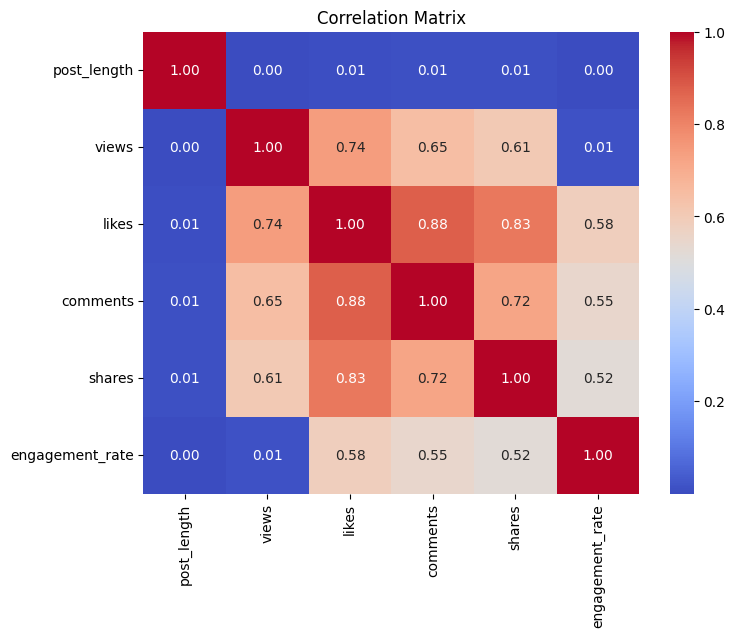

In [3]:
numeric_cols = [
    'post_length',
    'views',
    'likes',
    'comments',
    'shares',
    'engagement_rate'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

Exploratory Visulaizations

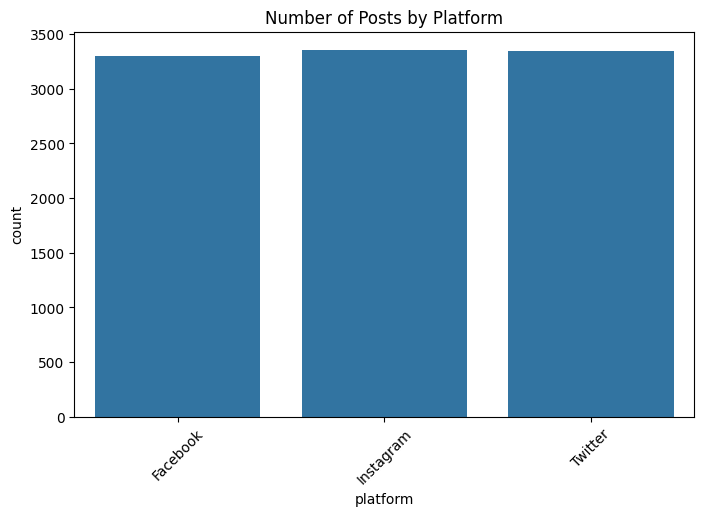

In [5]:
# Posts by Platform
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='platform')
plt.title('Number of Posts by Platform')
plt.xticks(rotation=45)
plt.show()

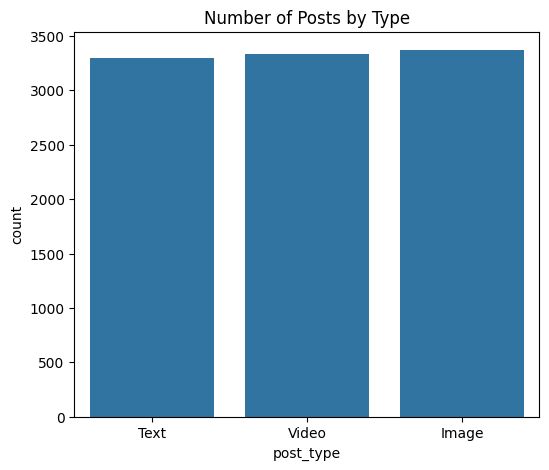

In [6]:
# Posts by Content Type
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='post_type')
plt.title('Number of Posts by Type')
plt.show()

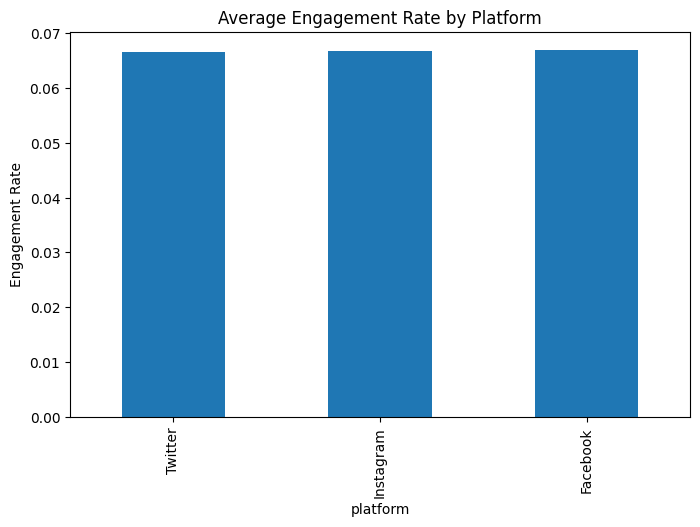

In [7]:
# Average Engagement Rate by Platform
platform_engagement = df.groupby('platform')['engagement_rate'].mean().sort_values()

plt.figure(figsize=(8,5))
platform_engagement.plot(kind='bar')
plt.title('Average Engagement Rate by Platform')
plt.ylabel('Engagement Rate')
plt.show()

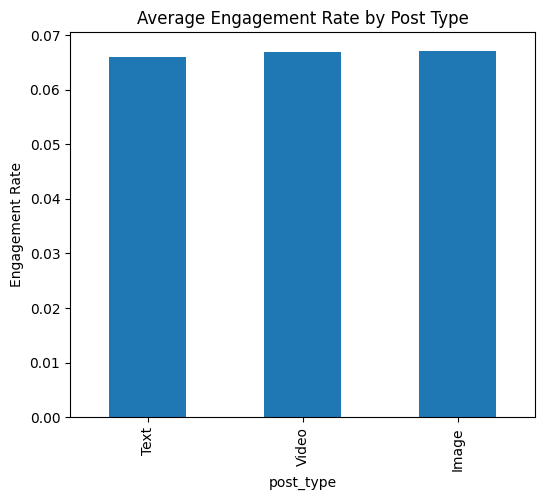

In [8]:
# Average Engagement Rate by Post Type
post_engagement = df.groupby('post_type')['engagement_rate'].mean().sort_values()

plt.figure(figsize=(6,5))
post_engagement.plot(kind='bar')
plt.title('Average Engagement Rate by Post Type')
plt.ylabel('Engagement Rate')
plt.show()

Outlier Analysis

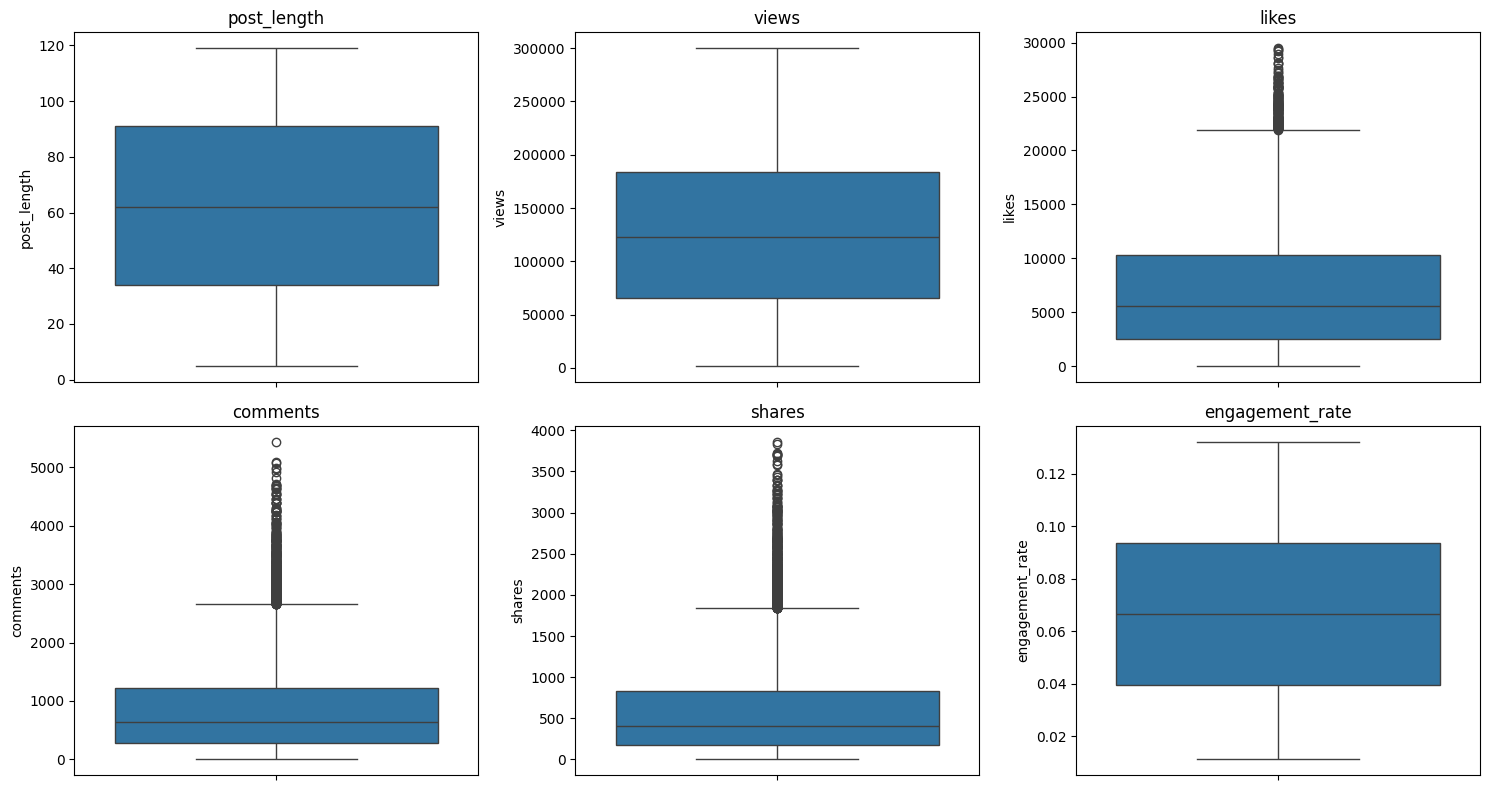

In [9]:
numeric_cols = [
    'post_length',
    'views',
    'likes',
    'comments',
    'shares',
    'engagement_rate'
]

plt.figure(figsize=(15,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,3,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Feature Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

features = [
    'post_length',
    'views',
    'likes',
    'comments',
    'shares',
    'engagement_rate'
]

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(10000, 6)


Optimal Number of Clusters
(Elbow Method)

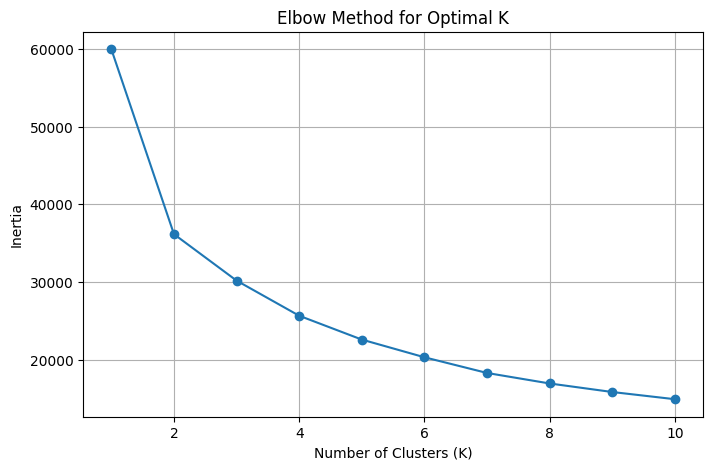

In [11]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

Adding the Silhouette Score to make it Strong

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, Silhouette Score={score:.4f}")

K=2, Silhouette Score=0.3629
K=3, Silhouette Score=0.2454
K=4, Silhouette Score=0.2285
K=5, Silhouette Score=0.2286
K=6, Silhouette Score=0.2200


K-Means Model

In [13]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

df['kmeans_cluster'].value_counts().sort_index()

,count
kmeans_cluster,
0,2455
1,1142
2,2887
3,3516


In [14]:
# Profiling the Clusters
cluster_profile = df.groupby('kmeans_cluster')[
    [
        'post_length',
        'views',
        'likes',
        'comments',
        'shares',
        'engagement_rate'
    ]
].mean()

print(cluster_profile)

                post_length          views         likes     comments  \
kmeans_cluster                                                          
0                 61.898982   53101.476578   3836.625662   468.340122   
1                 62.666375  221625.498249  18186.384413  2477.857268   
2                 62.922411  173559.506062  10409.286803  1250.284378   
3                 62.120023  110066.202503   2870.680887   342.226678   

                     shares  engagement_rate  
kmeans_cluster                                
0                312.211405         0.087429  
1               1763.731173         0.102469  
2                844.676827         0.076277  
3                228.494027         0.032734  


Visualizing the Clusters (PCA)

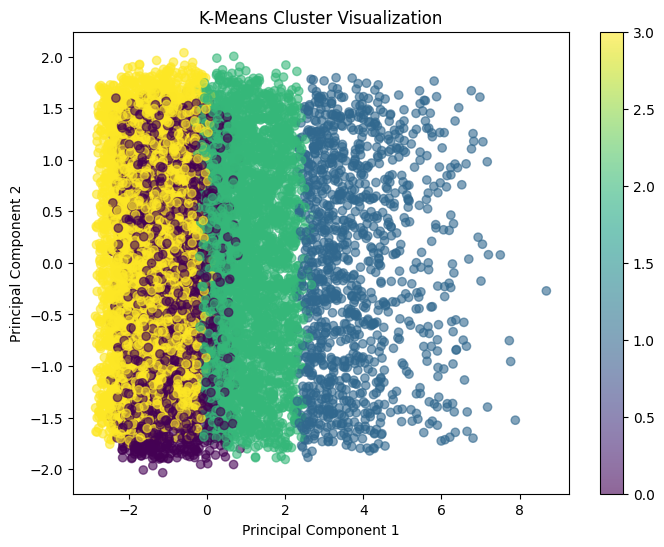

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['kmeans_cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Cluster Visualization')

plt.colorbar(scatter)
plt.show()

Obatining the Final K-Means

In [16]:
from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(
    X_scaled,
    df['kmeans_cluster']
)

print("K-Means Silhouette Score:", round(kmeans_score,4))

K-Means Silhouette Score: 0.2285


DBSCAN

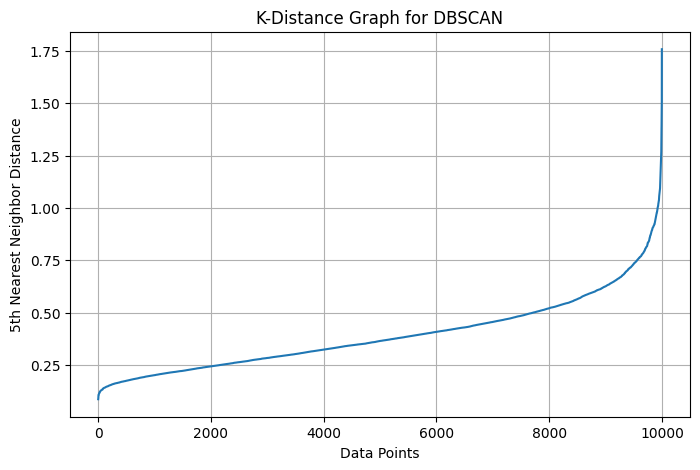

In [17]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = NearestNeighbors(n_neighbors=5)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,4])

plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title('K-Distance Graph for DBSCAN')
plt.xlabel('Data Points')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True)
plt.show()

In [18]:
# Fitting the DBSCAN
from sklearn.cluster import DBSCAN
import pandas as pd

dbscan = DBSCAN(
    eps=0.75,
    min_samples=5
)

df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

print(df['dbscan_cluster'].value_counts().sort_index())

dbscan_cluster
-1     207
 0    9736
 1       7
 2       5
 3      11
 4       5
 5       6
 6       6
 7       7
 8       5
 9       5
Name: count, dtype: int64


In [19]:
noise_points = (df['dbscan_cluster'] == -1).sum()

noise_percentage = (noise_points / len(df)) * 100

print("Noise Points:", noise_points)
print("Noise Percentage:", round(noise_percentage,2), "%")

Noise Points: 207
Noise Percentage: 2.07 %


DBSCAN Visualization

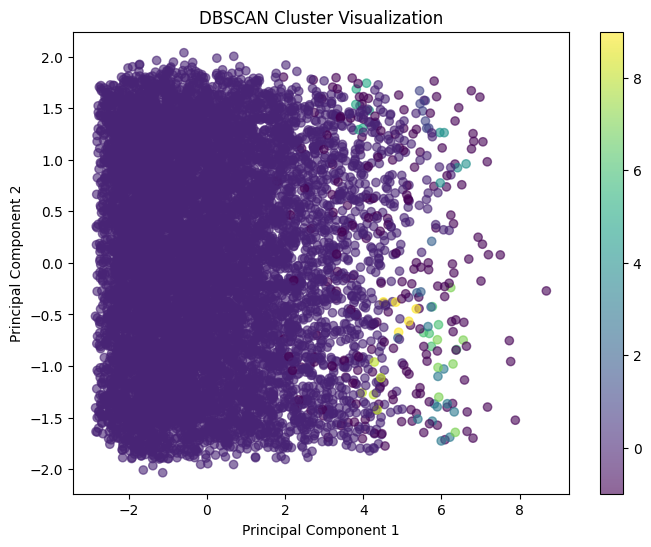

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_pca = PCA(n_components=2).fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['dbscan_cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.title('DBSCAN Cluster Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.colorbar(scatter)

plt.show()